### Notebook used to visualize the generated datasets

In [2]:
%cd C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM

C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM


Visualizing 2 samples from flumy_batch_0002.h5...


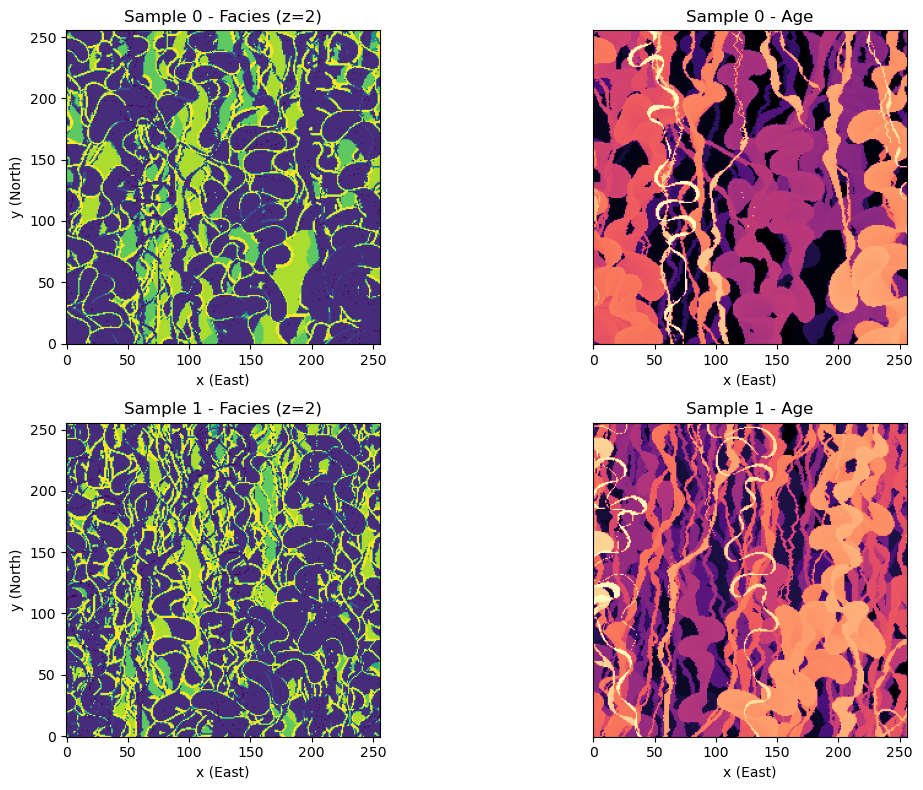

In [6]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

def visualize_h5_batch(file_path, max_samples=5, slice_axis='y', slice_idx=None):
    """
    Visualizes samples from a single HDF5 batch file.
    
    Args:
        file_path (str): Path to the .h5 file.
        max_samples (int): Maximum number of samples to display.
        slice_axis (str): 'x', 'y', or 'z' (direction to slice through).
        slice_idx (int): Index to slice at. If None, uses the middle of the volume.
    """
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return

    with h5py.File(file_path, 'r') as f:
        # 1. Get total available samples in this file
        total_in_file = f['facies'].shape[0]
        n_show = min(total_in_file, max_samples)
        
        print(f"Visualizing {n_show} samples from {os.path.basename(file_path)}...")
        
        # 2. Setup Figure
        fig, ax = plt.subplots(nrows=n_show, ncols=2, figsize=(12, 4 * n_show))
        
        # Handle single sample case (matplotlib squeeze behavior)
        if n_show == 1:
            ax = np.expand_dims(ax, axis=0)

        # 3. Loop through the samples inside the HDF5
        for i in range(n_show):
            # Load the 3D volume for the i-th sample
            # Shape is (nx, ny, nz)
            fac_vol = f['facies'][i]
            age_vol = f['age'][i]
            
            # 4. Determine Slicing Logic
            nx, ny, nz = fac_vol.shape
            
            if slice_axis == 'z': # Map View (Top-down)
                idx = slice_idx if slice_idx is not None else nz // 2
                slc_fac = fac_vol[:, :, idx]
                slc_age = age_vol[:, :, idx]
                ylabel = "y (North)"
                xlabel = "x (East)"
                aspect = 'equal'
                
            elif slice_axis == 'y': # Cross-section (Side view along Y)
                idx = slice_idx if slice_idx is not None else ny // 2
                # We transpose (.T) to put Z on vertical axis for geological view
                slc_fac = fac_vol[:, idx, :].T 
                slc_age = age_vol[:, idx, :].T
                ylabel = "z (Depth)"
                xlabel = "x (East)"
                aspect = 'auto' # Often better for Z-exaggeration
                
            elif slice_axis == 'x': # Cross-section (Side view along X)
                idx = slice_idx if slice_idx is not None else nx // 2
                slc_fac = fac_vol[idx, :, :].T
                slc_age = age_vol[idx, :, :].T
                ylabel = "z (Depth)"
                xlabel = "y (North)"
                aspect = 'auto'

            # 5. Plotting
            # -- Column 1: Facies --
            ax[i, 0].imshow(slc_fac, origin='lower', cmap='viridis', aspect=aspect)
            ax[i, 0].set_title(f"Sample {i} - Facies ({slice_axis}={idx})")
            ax[i, 0].set_ylabel(ylabel)
            ax[i, 0].set_xlabel(xlabel)

            # -- Column 2: Age --
            ax[i, 1].imshow(slc_age, origin='lower', cmap='magma', aspect=aspect)
            ax[i, 1].set_title(f"Sample {i} - Age")
            ax[i, 1].set_xlabel(xlabel)
            # Remove y-ticks for the second plot to clean up look
            ax[i, 1].set_yticks([])

    plt.tight_layout()
    plt.show()

# --- Usage Example ---
# Point this to one of your generated batch files
file_path = os.path.join("data", "datasets", "training", "flumy_batch_0002.h5")

# View 3 samples, cutting through the Y-axis (Cross-section) at index 50
visualize_h5_batch(file_path, max_samples=10, slice_axis='z', slice_idx=2)